In [1]:
import polars as pl
import numpy as np 
import seaborn as sns
import pandas as pd


1. Quando leio uma colua de string é mais custoso que coluna numérica
2. Quando são diferentes não há o que fazer
3. mas quando são repetitivas, posso otimizar usando:
3.1. No Polars: .cast(pl.Categorical)
3.2.No Pandas: .astype('category)


In [3]:
# a linha abaixo faz com que o dicionário que mapeia um número em relação a categoria seja global, ou seja, vai ser utilizado por qualquer outra tabela que seja lida no arquivo.

df = pl.read_csv('03.BaseDPEvolucaoMensalCisp.csv', separator=';', encoding='iso-8859-1')

df_dp = pl.read_csv('08.DP.csv', separator=',')

df = df.join(df_dp, left_on='cisp', right_on='codDP', how='left')

df.glimpse()



Rows: 34848
Columns: 65
$ cisp                       <i64> 1, 4, 5, 6, 7, 9, 10, 12, 13, 14
$ mes                        <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ ano                        <i64> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003
$ mes_ano                    <str> '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01'
$ aisp                       <i64> 5, 5, 5, 1, 1, 2, 2, 19, 19, 23
$ risp                       <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ munic                      <str> 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro'
$ mcirc                      <i64> 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557
$ regiao                     <str> 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Ca

In [4]:
df = df.with_columns(pl.col('munic').cast(pl.Categorical), pl.col('regiao').cast(pl.Categorical), pl.col('nome').cast(pl.Categorical))

In [25]:
# correlação entre coluna 1 e coluna 2

coluna1 = 'roubo_veiculo'
coluna2 = 'recuperacao_veiculos'

corr = df.select(pl.corr(coluna1, coluna2)).item()

print(corr)

0.8454989636146697


In [ ]:
# analises por munic 

df_municipio_agg = (df.group_by('munic').agg([pl.mean(coluna1).alias(f'Media_{coluna1}'), pl.mean(coluna2).alias(f'Media_{coluna2}')]))

df_municipio_agg.select(pl.corr(f'Media_{coluna1}', f'Media_{coluna2}'))



Media_roubo_veiculo
f64
0.974349


In [24]:
# analises por munic + ano 

df_municipio_ano_agg = (df.group_by(['munic', 'ano']).agg([pl.sum(coluna1).alias(f'Total_{coluna1}'), pl.sum(coluna2).alias(f'Total_{coluna2}')]))

df_municipio_ano_agg.select(pl.corr(f'Total_{coluna1}', f'Total_{coluna2}'))


Total_roubo_veiculo
f64
0.991941


In [26]:
df_municipio_ano_agg = (df.group_by(['munic', 'ano']).agg([pl.corr(coluna1, coluna2).alias(f'correlacao_{coluna1}_{coluna2}')]).sort('ano'))

df_municipio_ano_agg.filter(pl.col('munic') == 'Rio de janeiro')

df_municipio_ano_agg

munic,ano,correlacao_roubo_veiculo_recuperacao_veiculos
cat,i64,f64
"""Comendador Levy Gasparian;Area…",2003,-0.053398
"""Mangaratiba""",2003,0.711202
"""Magé""",2003,-0.214377
"""Laje do Muriaé""",2003,NaN
"""Itaocara""",2003,-0.314834
…,…,…
"""Miracema""",2024,NaN
"""Quissamã;Carapebus""",2024,0.265165
"""São Pedro da Aldeia""",2024,0.234044


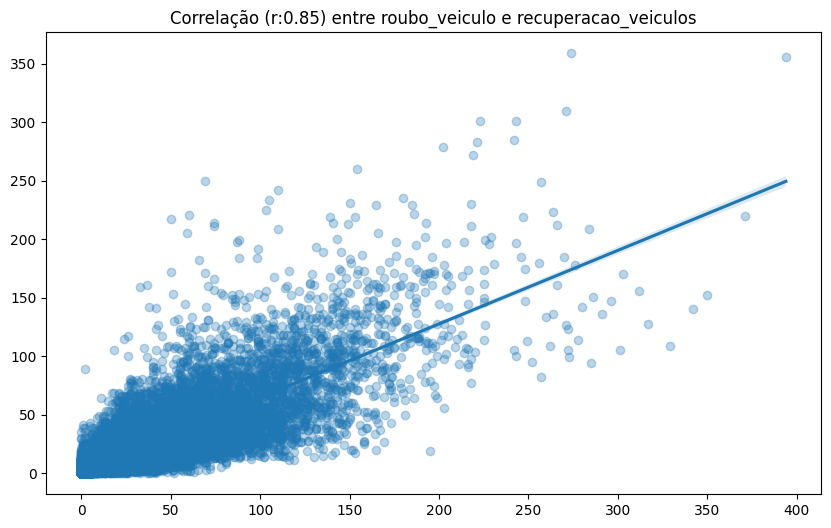

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.regplot(data=df, x=coluna1, y=coluna2, scatter_kws={'alpha': 0.3})

plt.title(f'Correlação (r:{corr:.2f}) entre {coluna1} e {coluna2}')
plt.show()